You used to key document data into your system by hand. Then you automated extraction with Azure Content Understanding, but a person still reviews every extracted value. That feels safe, but it's slow and expensive, and it keeps much of the manual work you meant to remove.

What if Content Understanding could tell you how confident it is in each value, so a person only checks the ones worth checking? It can: each extracted value can come back with a confidence score. But one cutoff shared by every field is a blunt tool, because a score you can trust for one field can mean very little for another. This recipe gives each field its own cutoff instead, all set by one dial: **the share of mistakes human review must catch**. Fields whose confidence can't tell correct values from mistakes get no cutoff and stay in review.

Blank values get their own rule. When Content Understanding returns nothing for a field, the confidence attached is a fixed placeholder, so the recipe ignores it and instead approves or reviews each field's blanks based on how often they turn out to be truly blank.

The recipe runs on 1,000 receipts from the public [CORD v2](https://huggingface.co/datasets/naver-clova-ix/cord-v2) dataset, already processed by Content Understanding and checked against the dataset's correct answers, so every mistake is known. You tune on 800 receipts and test on the other 200.

With the dial at 80%, the policy approves **28% of the test values without review** and still catches **85% of the mistakes**, beating the target, and 10% of what it approves is wrong. A single 0.80 cutoff on every value approves about as much (30%), but catches only 71% of mistakes, and 18% of what it approves is wrong. About half the saving comes from handling blanks this way, and the per-field cutoffs hold each field you approve to your dial. What you ship is a small CSV with one row per field, and routing a new value is a dictionary lookup and a comparison.

[![The interactive explainer: Stop reviewing everything.](media/acu-dynamic-hitl/01-explainer-hero.png)](../media/acu-dynamic-hitl/dynamic-hitl-explainer.html)

**[Open the interactive explainer](../media/acu-dynamic-hitl/dynamic-hitl-explainer.html)** for a six-part visual walkthrough of the method, driven by the same numbers this notebook computes on the bundled receipts.

## Background

[Azure Content Understanding](https://learn.microsoft.com/azure/ai-services/content-understanding/overview) is a Foundry Tool that uses generative AI to turn unstructured content into structured output. For document processing, you define an analyzer's field schema, such as an invoice number and total amount, and the analyzer extracts those values. You can use the output in automation or analytics, for tasks such as invoice processing or contract analysis.

For documents, you can enable [confidence scores and grounding](https://learn.microsoft.com/azure/ai-services/content-understanding/concepts/analyzer-reference#estimatefieldsourceandconfidence) with `estimateFieldSourceAndConfidence`. A score from 0 to 1 estimates an extracted value's accuracy; higher means more confidence. Grounding shows where on the page the value came from so a reviewer can check it.

The common pattern, which Microsoft Learn suggests, is human-in-the-loop (HITL) review: values above a confidence threshold go straight into your systems without review, called straight-through processing (STP), and the rest go to a person. In the CORD receipt data this recipe uses, one threshold can't serve every field. Confidence is a useful guide for the receipt's total (`total_price`), but for its tax amount (`tax_price`) it isn't reliably better than chance.

### How the routing works

The recipe uses the checked values to tune a rule for each field, with separate paths for blank and filled-in values.

![Routing: blank values go to the blank track, filled-in values pass a signal gate and a field cutoff, everything else goes to a person.](media/acu-dynamic-hitl/02-explainer-routing.png)

- **Blank values** are judged on one question per field: when Content Understanding returns nothing, is the field reliably blank? Content Understanding gives blanks a placeholder score, so no cutoff can sort them.
- **Filled-in values** must pass a signal gate first. A field earns a cutoff only if its confidence demonstrably ranks correct values above mistakes. Otherwise every filled-in value in that field goes to review.
- **Anything that fails either test goes to a person.** Too little evidence means review, so thin data costs you savings, not missed mistakes.

## Overview

**Who this is for:** developers and data scientists running document extraction with Content Understanding who send every extracted value to a person for review today and want to be more strategic about what gets reviewed.

**What you'll learn:**

- Measure whether each field's confidence is worth trusting, instead of picking one global cutoff.
- Set one business dial and turn it into a per-field calibration table.
- Deploy that table with a standard-library routing function, then compare it against a global cutoff on unseen documents.
- Configure a Content Understanding analyzer in Microsoft Foundry to return confidence scores, and flatten its output into calibration rows.

**Prerequisites:**

- Python 3.10 or later. Steps 1 through 6 run on bundled, measured Content Understanding output and **need no Azure credentials**.
- For the optional step 7: a Microsoft Foundry resource with Content Understanding, the **Cognitive Services User** role on it, default model deployments configured for Content Understanding, and the `CONTENTUNDERSTANDING_ENDPOINT` environment variable set.

**Time estimate:** about 10 minutes. Measuring the signal takes about a minute.

## Outline

1. Set up and load the data
2. Measure the signal in each field
3. Turn the business dial
4. Save the calibration table
5. Deploy it: route unseen documents
6. Bring your own data
7. Optional: get confidence-scored output from Content Understanding in Foundry

## 1. Set up and load the data

The recipe's helpers live next to the notebook in `data/acu-dynamic-hitl/`: the calibration library (`calibration.py`, `acu_calibrator.py`, `matching.py`), the mistake catch-rate dial renderer (`hitl_dial.py`), and the bundled data. Install the dependencies once.

In [ ]:
%pip install --quiet -r data/acu-dynamic-hitl/requirements.txt

The bundled dataset is **measured** Content Understanding output for 1,000 [CORD v2](https://huggingface.co/datasets/naver-clova-ix/cord-v2) receipts (CC BY 4.0), not a simulation. It has one row per extracted field value: what Content Understanding returned, its confidence, and whether it matched ground truth. 800 documents calibrate the policy and 200 are held out to test it.

In [2]:
import sys

sys.path.insert(0, "data/acu-dynamic-hitl/")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

import calibration as calib
import matching
import hitl_dial

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
# Jupyter right-aligns table values to match pandas' headers; do the same in renderers that don't.
display(HTML("<div><style>.dataframe td { text-align: right; } .dataframe tbody th, .dataframe thead th:first-child { text-align: left; }</style></div>"))

data = calib.load_demo_data("data/acu-dynamic-hitl/cord_demo.parquet")
documents = data.groupby("split")["document_id"].nunique()

print(f"{len(data):,} extracted field values")
print(f"{documents['train']:,} documents to calibrate on, {documents['test']:,} held out\n")
data[["document_id", "split", "field_name", "extracted_value", "confidence", "is_correct"]].head(3)

13,853 extracted field values
800 documents to calibrate on, 200 held out



,document_id,split,field_name,extracted_value,confidence,is_correct
0,cord-train-0000,train,subtotal_price,"1,346,000",0.862,True
1,cord-train-0000,train,service_price,"100,950",0.873,True
2,cord-train-0000,train,tax_price,"144,695",0.873,True


The baseline everyone starts from: **every value is reviewed by a person**, to find the mistakes hiding among them.

In [3]:
train = calib.calibration_input(data, split="train")
mistakes = int((~train["is_correct"].astype(bool)).sum())

print(f"Training split: {len(train):,} values, {mistakes:,} of them wrong ({mistakes / len(train):.1%})")

Training split: 11,143 values, 2,001 of them wrong (18.0%)


## 2. Measure the signal in each field

**When to use:** once per document type, on labeled documents.

**What it does:** for each field, it cross-validates (grouped by document, so line items from one receipt never span folds), bootstraps a confidence interval on AUC, measures how often a blank is genuinely blank, and sweeps every candidate cutoff. Everything is cached, so changing the target later costs nothing.

**How to read it:**

- **`auc`**: how often confidence puts a correct value above a wrong one. 0.5 is a coin flip.
- **`confidence_is_usable`**: the field earns a cutoff only if the *lower* end of its AUC interval clears 0.5. This bar is the most consequential setting in the method.
- **`blank_precision`**: how often a blank from this field really is blank. Its lower bound decides whether blanks can skip review.

**How to adapt:** the AUC bar is `calib.MIN_AUC_CI_LOWER` (default 0.50, the loosest bar that still beats a coin flip). Set it before fitting, for example `calib.MIN_AUC_CI_LOWER = 0.55`, then re-run this cell.

In [4]:
base_policies = calib.fit_base_policies(data, split="train")

calib.signal_frame(base_policies).set_index("field_name")[
    ["n_filled", "auc", "auc_ci_lower", "confidence_is_usable", "n_blank", "blank_precision", "blank_ci_lower"]
].round(3)

,n_filled,auc,auc_ci_lower,confidence_is_usable,n_blank,blank_precision,blank_ci_lower
field_name,,,,,,,
menu.name,2373,0.576,0.531,True,8,1.000,0.676
menu.price,2210,0.591,0.531,True,171,0.667,0.593
menu.quantity,2091,0.550,0.493,False,290,0.790,0.739
other_adjustment,109,0.596,0.470,False,691,0.961,0.944
service_price,189,0.587,0.501,True,611,1.000,0.994
subtotal_price,653,0.602,0.553,True,147,0.966,0.923
tax_price,260,0.507,0.371,False,540,0.820,0.786
total_price,790,0.589,0.527,True,10,0.200,0.057


Five of the eight fields carry usable signal. `menu.quantity`, `other_adjustment`, and `tax_price` do not: their AUC interval reaches below 0.5, so their filled-in values stay in full review no matter where you set the dial. Raise the bar to 0.55 and only one field still qualifies; that is how sensitive the result is to this setting.

## 3. Turn the business dial

**When to use:** whenever the business changes how much risk it accepts.

**What it does:** one number, `TARGET`, is the minimum share of known mistakes review must catch. Each field gets the cutoff that meets that floor with the least review. Nothing is refit; the cached signal is reused.

**How to adapt:** change `TARGET` and re-run from here. To vary it per field, pass a mapping that covers every field, for example `{**{field: TARGET for field in base_policies}, "total_price": 0.95}`.

`TARGET` is a floor on the fields that earn a cutoff, not a portfolio promise, and not a promise that auto-approved values are `TARGET` correct. Those are different denominators. Step 5 measures both on unseen documents.

In [5]:
TARGET = 0.80

policies = calib.select_policies(base_policies, TARGET)
calib.calibration_table(policies)[
    ["field_name", "filled_decision", "cutoff", "blank_decision", "target_catch_rate", "min_null_precision"]
].round(3)

,field_name,filled_decision,cutoff,blank_decision,target_catch_rate,min_null_precision
0,menu.name,calibrate,0.796,insufficient_nulls,0.8,0.8
1,menu.price,calibrate,0.875,null_to_hitl,0.8,0.8
2,menu.quantity,always_review,NaN,null_to_hitl,0.8,0.8
3,other_adjustment,always_review,NaN,null_to_stp,0.8,0.8
4,service_price,calibrate,0.864,null_to_stp,0.8,0.8
5,subtotal_price,calibrate,0.856,null_to_stp,0.8,0.8
6,tax_price,always_review,NaN,null_to_hitl,0.8,0.8
7,total_price,calibrate,0.845,null_to_hitl,0.8,0.8


In the table, `filled_decision` is `calibrate` when a field earned a cutoff and `always_review` when it didn't. `blank_decision` says what happens when Content Understanding returns nothing for the field: `null_to_stp` approves the blank without review (straight-through processing), and `null_to_hitl` sends it to a person (human in the loop). A value of `insufficient_nulls` means there were too few blanks in training data to judge, so they go to a person.

Where the saving comes from, on the training split:

In [6]:
per_field, portfolio = calib.savings_attribution(policies, train)

print(f"Review avoided at the {TARGET:.0%} target: {portfolio['hitl_savings_pct']:.1%}")
print(f"  from blank values:     {portfolio['null_savings_pct']:.1%}")
print(f"  from filled-in values: {portfolio['lr_savings_pct']:.1%}")

per_field[["field", "bucket", "n_total", "null_savings", "lr_savings", "expected_hitl", "hitl_savings_pct"]].round(3)

Review avoided at the 80% target: 27.2%
  from blank values:     13.0%
  from filled-in values: 14.2%


,field,bucket,n_total,null_savings,lr_savings,expected_hitl,hitl_savings_pct
0,menu.name,calibrate,2381,0,453,1928,0.190
1,menu.price,calibrate,2381,0,633,1748,0.266
2,menu.quantity,always_review,2381,0,0,2381,0.000
3,other_adjustment,always_review,800,691,0,109,0.864
4,service_price,calibrate,800,611,50,139,0.826
5,subtotal_price,calibrate,800,147,190,463,0.421
6,tax_price,always_review,800,0,0,800,0.000
7,total_price,calibrate,800,0,253,547,0.316


Splitting blanks from filled-in values does about half the work. Fields like `service_price` and `other_adjustment` are blank on most receipts, and their blanks are reliable, so most of their values never need a person to review them.

### Try every target at once

The dial below is precomputed from the same `base_policies` at 11 targets. The top half shows expected savings on the training split. **Caught on unseen documents** and **Slipped through** are measured on the 200 held-out receipts. Pick a target to compare. It is plain HTML and CSS, so it works in Jupyter, VS Code, and static notebook viewers.

In [7]:
positions = hitl_dial.dial_positions(base_policies, data)
display(HTML(hitl_dial.render_dial(positions, default=TARGET)))

The dial is a real tradeoff. Ask review to catch more and you give up automation, mostly on the filled-in track, because the blank track is a per-field on/off switch rather than a sliding cutoff. The same tradeoff across the full range:


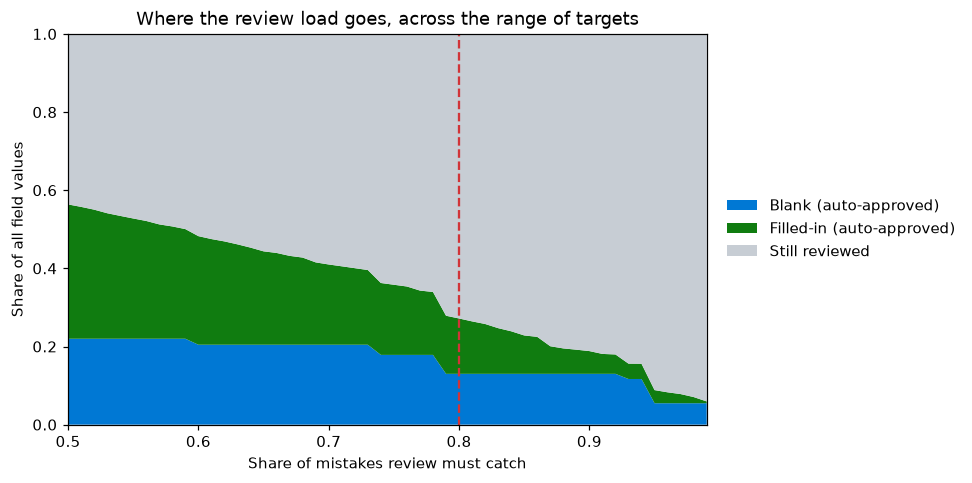

In [8]:
sweep = calib.savings_sweep(base_policies, train, start=0.50, end=0.99, step=0.01)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.stackplot(
    sweep["target"],
    sweep["null_savings_pct"],
    sweep["lr_savings_pct"],
    sweep["hitl_load"],
    labels=["Blank (auto-approved)", "Filled-in (auto-approved)", "Still reviewed"],
    colors=["#0078d4", "#107c10", "#c7cdd4"],
)
ax.axvline(TARGET, color="#d13438", linestyle="--", linewidth=1.5)
ax.set_xlim(0.50, 0.99)
ax.set_ylim(0, 1)
ax.set_xlabel("Share of mistakes review must catch")
ax.set_ylabel("Share of all field values")
ax.set_title("Where the review load goes, across the range of targets")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
display(HTML(hitl_dial.figure_html(
    fig,
    alt=(
        "Stacked area chart of where the review load goes as the catch target rises from 50% to 99%: "
        f"blank values auto-approved, filled-in values auto-approved, and values still reviewed. "
        f"At the {TARGET:.0%} target, {portfolio['hitl_savings_pct']:.0%} of values skip review."
    ),
)))

## 4. Save the calibration table

The table is the whole deliverable: one row per field with the decision, the cutoff, the targets it was calibrated to, and a plain-English `why`. Production needs this file and nothing else from calibration. Each run rewrites it with a new `calibrated_at` timestamp.

In [9]:
TABLE_PATH = f"data/acu-dynamic-hitl/calibration_table_{round(TARGET * 100)}pct.csv"

saved = calib.save_calibration_table(policies, TABLE_PATH)
print(f"wrote {saved.as_posix()}  ({saved.stat().st_size:,} bytes)\n")
print(saved.read_text().splitlines()[0])

wrote data/acu-dynamic-hitl/calibration_table_80pct.csv  (1,279 bytes)

field_name,filled_decision,cutoff,score_mode,lr_coef,lr_intercept,blank_decision,target_catch_rate,min_null_precision,calibrated_at,why


## 5. Deploy it: route unseen documents

This is the production path. Load the CSV back, so the fitted objects and labeled data are gone, and route the 200 held-out documents through it.

Read `stp_error_rate` per field, not just the portfolio figure. The dial controls how many mistakes review catches. It does not cap how wrong the auto-approved values are, and that rate varies widely by field.

The last line reports line items Content Understanding never returned. They're left out of these figures because there's no extracted value to route, so value-level review can't catch them. Catch them with a document-level check, such as comparing the sum of item prices with the subtotal.

> **Important:** If the data you extract is sensitive, keep a person on every value and use this policy to set priorities instead of skipping review. Load every value into your human-in-the-loop (HITL) review tool, labeled with the decision and `route_reason` from `route_value` (defined below). Reviewers work through the values the policy sends to review first and confirm the rest more quickly. They still see everything, and the calibration tells them where mistakes are most likely.

In [10]:
shipped = calib.load_calibration_table(TABLE_PATH)

routed = calib.route_frame(data, shipped, split="test")
held_out, totals = calib.held_out_metrics(routed)

print(f"On {routed['document_id'].nunique()} unseen documents ({totals['field_values']:,} values):")
print(f"  auto-approved:            {totals['auto_approve_rate']:.1%}")
print(f"  mistakes caught:          {totals['catch_rate']:.1%}  (asked for {TARGET:.0%})")
print(f"  mistakes slipped through: {totals['stp_error_rate']:.1%} of auto-approved values")

missed = calib.missed_line_items(data, split="test")
print(f"\nLine items never extracted (reported separately): {missed['items']} in {missed['documents']} documents, "
      f"{missed['mistakes']} mistakes")

held_out.set_index("field_name")[
    ["auto_approve_rate", "catch_rate", "stp_error_rate", "mistakes_caught", "total_mistakes"]
].round(3)

On 200 unseen documents (2,617 values):
  auto-approved:            28.5%
  mistakes caught:          84.7%  (asked for 80%)
  mistakes slipped through: 9.7% of auto-approved values



Line items never extracted (reported separately): 8 in 7 documents, 21 mistakes


,auto_approve_rate,catch_rate,stp_error_rate,mistakes_caught,total_mistakes
field_name,,,,,
menu.name,0.232,0.774,0.280,120,155
menu.price,0.250,0.786,0.133,66,84
menu.quantity,0.000,1.000,NaN,98,98
other_adjustment,0.900,0.826,0.022,19,23
service_price,0.850,0.739,0.035,17,23
subtotal_price,0.390,0.872,0.064,34,39
tax_price,0.000,1.000,NaN,32,32
total_price,0.290,0.765,0.069,13,17


### When one field slips too much

`menu.name` auto-approves about 23% of its values, and 28% of those are wrong. Its confidence barely ranks correct values above mistakes (AUC 0.58), so raising its target only shrinks the auto-approved slice without making it much cleaner. When a field's slip rate is more than the business accepts, take it out of the table: a field with no row always routes to review.

In [11]:
strict = {field: rule for field, rule in shipped.items() if field != "menu.name"}
_, strict_totals = calib.held_out_metrics(calib.route_frame(data, strict, split="test"))

pd.DataFrame({"as calibrated": totals, "menu.name always reviewed": strict_totals}).loc[
    ["auto_approve_rate", "catch_rate", "stp_error_rate"]
].round(3)

,as calibrated,menu.name always reviewed
auto_approve_rate,0.285,0.237
catch_rate,0.847,0.921
stp_error_rate,0.097,0.060


Forcing one weak field to review gives up about 5 points of automation for a much cleaner auto-approved stream. That's a business call, and the table makes it explicit and reversible.

Every routed value carries a `route_reason`, so any decision can be explained after the fact and checked against ground truth:

In [12]:
audit = (
    routed.groupby("route_reason")
    .agg(
        values=("is_correct", "size"),
        sent_to_review=("route_to_hitl", "sum"),
        mistakes=("is_correct", lambda s: int((~s.astype(bool)).sum())),
        mistakes_slipped=("stp_error", "sum"),
    )
    .sort_values("values", ascending=False)
)
audit

,values,sent_to_review,mistakes,mistakes_slipped
route_reason,,,,
raw_below_threshold,1058,1058,238,0
non_null_uncalibrated,564,564,109,0
raw_above_threshold,380,0,68,68
null_policy_stp,366,0,4,4
null_policy_review,249,249,52,0


### Compare against one shared cutoff

The table scores four policies on the same held-out documents. The shared cutoff for filled-in values is chosen on training data to approve the same share as the per-field policy; the 0.80 row is a common starting point that applies one cutoff to every value, blanks included.

In [13]:
import numpy as np


def approvals(frame, shared_cutoff=None):
    """Blanks approved by each field's blank rule, plus filled-in values at or above one shared cutoff."""
    approved = frame["route_reason"].eq("null_policy_stp")
    if shared_cutoff is not None:
        filled = ~frame["extracted_value"].map(matching.is_null)
        approved |= filled & (pd.to_numeric(frame["confidence"], errors="coerce") >= shared_cutoff)
    return approved


def outcome(frame, approved):
    wrong = ~frame["is_correct"].astype(bool)
    return {
        "auto-approved": approved.mean(),
        "mistakes caught": (wrong & ~approved).sum() / wrong.sum(),
        "wrong among auto-approved": (wrong & approved).sum() / approved.sum(),
    }


# Chosen on the training split: the shared cutoff that approves as many values as the per-field policy.
train_routed = calib.route_frame(data, shipped, split="train")
train_share = (~train_routed["route_to_hitl"].astype(bool)).mean()
candidates = np.round(np.arange(0.50, 1.0, 0.005), 3)
shared_cutoff = min(candidates, key=lambda c: abs(approvals(train_routed, c).mean() - train_share))

confidence = pd.to_numeric(routed["confidence"], errors="coerce")
pd.DataFrame(
    {
        "one 0.80 cutoff on every value": outcome(routed, confidence >= 0.80),
        "blank rule only": outcome(routed, approvals(routed)),
        f"blank rule + one {shared_cutoff:.3f} cutoff": outcome(routed, approvals(routed, shared_cutoff)),
        "blank rule + per-field cutoffs": outcome(routed, ~routed["route_to_hitl"].astype(bool)),
    }
).T.round(3)

,auto-approved,mistakes caught,wrong among auto-approved
one 0.80 cutoff on every value,0.296,0.705,0.180
blank rule only,0.140,0.992,0.011
blank rule + one 0.860 cutoff,0.285,0.866,0.085
blank rule + per-field cutoffs,0.285,0.847,0.097


The blank rule alone approves 14.0% of values with only 1.1% wrong, delivering about half the saving with almost no errors. Applying 0.80 to every value catches far fewer mistakes (70.5% versus 84.7%) and is wrong about twice as often among approvals (18.0% versus 9.7%), mostly because it trusts blanks' placeholder scores. With the blank rule in place, one shared cutoff does about as well as per-field cutoffs in total. The next table shows what per-field cutoffs add.

In [14]:
filled = ~routed["extracted_value"].map(matching.is_null)
wrong_filled = filled & ~routed["is_correct"].astype(bool)
shared = approvals(routed, shared_cutoff) & filled
per_field = filled & ~routed["route_to_hitl"].astype(bool)
field = routed["field_name"]

pd.DataFrame(
    {
        "filled-in mistakes": wrong_filled.groupby(field).sum(),
        f"caught, one {shared_cutoff:.3f} cutoff": (wrong_filled & ~shared).groupby(field).sum() / wrong_filled.groupby(field).sum(),
        "caught, per-field cutoffs": (wrong_filled & ~per_field).groupby(field).sum() / wrong_filled.groupby(field).sum(),
    }
).round(3)

,filled-in mistakes,"caught, one 0.860 cutoff","caught, per-field cutoffs"
field_name,,,
menu.name,155,0.929,0.774
menu.price,73,0.699,0.753
menu.quantity,82,0.890,1.000
other_adjustment,19,0.895,1.000
service_price,23,0.739,0.739
subtotal_price,39,0.872,0.872
tax_price,8,0.875,1.000
total_price,16,0.812,0.750


Per-field cutoffs keep calibrated fields near the 80% dial on held-out data, catching 74% to 87% of each field's filled-in mistakes, and never auto-approve filled-in values in the three fields without usable signal. The shared cutoff ranges from 70% to 93% and lets 10% to 12% of mistakes through in those no-signal fields. The dial is a promise you can make per field, set on training data and checked on held-out data.

### Route one value with no labels and no pandas

`route_frame` needs ground truth because it also scores the outcome. In production you only have the extraction. The function below is the whole inference-time integration: read the CSV once, then look up the field and compare. It uses only the standard library and returns the same `route_reason` names as `route_frame`. The check after it confirms both the decision and the reason match on every held-out value.

In [15]:
import csv
import math


def load_table(path):
    with open(path, newline="", encoding="utf-8") as handle:
        return {row["field_name"]: row for row in csv.DictReader(handle)}


def is_blank(value):
    if value is None:
        return True
    if isinstance(value, float):
        return math.isnan(value)
    return isinstance(value, str) and not value.strip()


def route_value(table, field_name, value, confidence):
    """Return (send_to_review, route_reason) for one extracted value."""
    rule = table.get(field_name)
    if rule is None:
        return True, "unknown_field"
    if is_blank(value):
        review = rule["blank_decision"] != "null_to_stp"
        return review, "null_policy_review" if review else "null_policy_stp"
    if is_blank(confidence):
        return True, "missing_confidence"
    if rule["filled_decision"] == "always_trust":
        return False, "always_trust"
    if rule["filled_decision"] != "calibrate":
        return True, "non_null_uncalibrated"
    score, prefix = float(confidence), "raw"
    if rule["score_mode"] == "logistic":
        score = 1 / (1 + math.exp(-(float(rule["lr_coef"]) * score + float(rule["lr_intercept"]))))
        prefix = "lr"
    review = score < float(rule["cutoff"])
    return review, f"{prefix}_below_threshold" if review else f"{prefix}_above_threshold"


table = load_table(TABLE_PATH)
results = [route_value(table, row.field_name, row.extracted_value, row.confidence) for row in routed.itertuples()]
same = sum(
    (review, reason) == (bool(expected_review), expected_reason)
    for (review, reason), expected_review, expected_reason in zip(
        results, routed["route_to_hitl"], routed["route_reason"]
    )
)
print(f"route_value matches route_frame's decision and reason on {same:,} of {len(routed):,} held-out values")

route_value matches route_frame's decision and reason on 2,617 of 2,617 held-out values


### Does the dial behave like a dial?

Sweep every target, rebuild on training documents only, and measure what the untouched test documents actually got.

The green line is the one the target governs. It tracks the diagonal but sits a little under it: each cutoff is the most aggressive one that cleared the target on the training split, so there is no margin to absorb the shift to unseen documents. The amber line runs higher because fully reviewed fields catch everything.


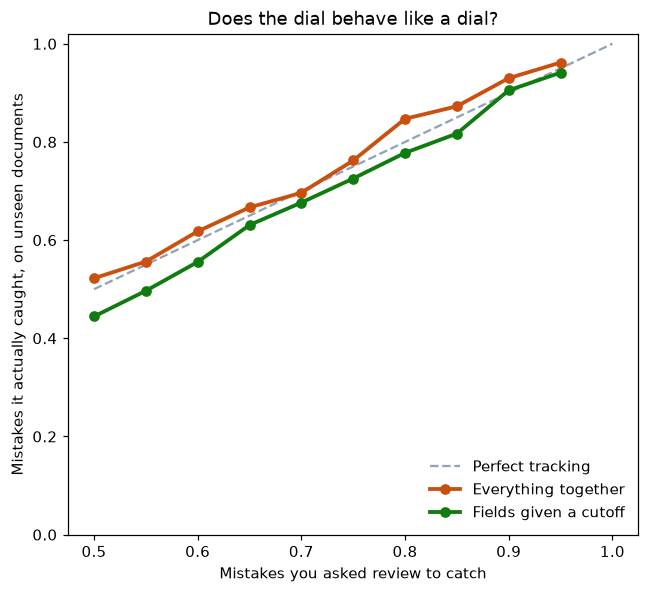

In [16]:
tracking = calib.coverage_tracking(base_policies, data, split="test", step=0.05)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0.5, 1.0], [0.5, 1.0], "--", color="#94a3b8", label="Perfect tracking")
ax.plot(tracking["target"], tracking["overall_catch"], "o-", color="#ca5010", linewidth=2.5, label="Everything together")
ax.plot(tracking["target"], tracking["calibrated_catch"], "o-", color="#107c10", linewidth=2.5, label="Fields given a cutoff")
ax.set_xlabel("Mistakes you asked review to catch")
ax.set_ylabel("Mistakes it actually caught, on unseen documents")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Does the dial behave like a dial?")
fig.tight_layout()
display(HTML(hitl_dial.figure_html(
    fig,
    alt=(
        "Line chart of the share of mistakes caught on unseen documents against the target, from 50% to 95%. "
        "The line for fields given a cutoff tracks just under the diagonal; "
        "the line for all fields together runs above it."
    ),
)))

If you need the held-out catch rate to stay at or above the target, calibrate to a slightly higher target than you promise, for example 0.85 to deliver 0.80.

## 6. Bring your own data

Everything above needs one table with these six columns, one row per extracted field value:

| column | meaning |
| --- | --- |
| `document_id` | which document the value came from |
| `split` | `train` or `test`; split by document, never by row |
| `field_name` | which field the value belongs to |
| `extracted_value` | what Content Understanding returned (`None` if nothing) |
| `confidence` | Content Understanding's confidence for that value, 0 to 1 |
| `is_correct` | whether it matched ground truth |

`matching.add_is_correct(frame)` fills in the last column by comparing `extracted_value` to a `ground_truth_value` column with per-field normalization. You define what "correct" means: too strict and you chase mistakes that were not mistakes; too loose and the policy certifies real ones. Build the frame, then point the notebook at it: in step 1, replace the `calib.load_demo_data(...)` line with `data = calib.load_canonical_file("my_data.parquet")` (Parquet or CSV), or assign your DataFrame to `data` directly. Restart the kernel and run all cells, so every result above, including the dial, is recomputed from your data instead of the receipts.

List fields, such as receipt line items, are named `<list>.<property>` (for example `menu.price`) and carry an `item_index`. Use `matching.pair_with_ground_truth` to pair items one-to-one by content within each document, not by position. Each item's `line_item_status` is `matched`, `missed` (in ground truth, never extracted), or `extra` (extracted, not in ground truth). Extra items count as mistakes; missed items are excluded from calibration and reported separately by `calib.missed_line_items`. Treat `weights` and `max_cost` as choices: check missed and extra counts, then spot-check pairs.

In the example below, `Iced tea` is `matched` even though it sits in a different position, `Coffee` is `missed`, and `Discount` is `extra`.

In [17]:
# Extracted rows, for example from to_canonical_rows in step 7. Line items carry an item_index.
extracted = pd.DataFrame(
    [
        {"document_id": "receipt-1", "field_name": "total_price", "item_index": None, "extracted_value": "13.00", "confidence": 0.93},
        {"document_id": "receipt-1", "field_name": "menu.name", "item_index": 0, "extracted_value": "Iced tea", "confidence": 0.88},
        {"document_id": "receipt-1", "field_name": "menu.price", "item_index": 0, "extracted_value": "4.00", "confidence": 0.91},
        {"document_id": "receipt-1", "field_name": "menu.name", "item_index": 1, "extracted_value": "Discount", "confidence": 0.64},
        {"document_id": "receipt-1", "field_name": "menu.price", "item_index": 1, "extracted_value": "-1.00", "confidence": 0.70},
    ]
)
# Your labels for the same documents. Line items don't need to be in the same order as the extraction.
truth = pd.DataFrame(
    [
        {"document_id": "receipt-1", "field_name": "total_price", "item_index": None, "ground_truth_value": "13.00"},
        {"document_id": "receipt-1", "field_name": "menu.name", "item_index": 0, "ground_truth_value": "Coffee"},
        {"document_id": "receipt-1", "field_name": "menu.price", "item_index": 0, "ground_truth_value": "9.00"},
        {"document_id": "receipt-1", "field_name": "menu.name", "item_index": 1, "ground_truth_value": "Iced Tea"},
        {"document_id": "receipt-1", "field_name": "menu.price", "item_index": 1, "ground_truth_value": "4.00"},
    ]
)

my_data = matching.pair_with_ground_truth(extracted, truth, weights={"name": 0.6, "price": 0.4})
my_data = matching.add_is_correct(my_data)
my_data["split"] = "train"  # assign splits by document, never by row
my_data

,document_id,field_name,item_index,ground_truth_value,extracted_value,confidence,line_item_status,is_correct,split
0,receipt-1,total_price,NaN,13.00,13.00,0.93,None,True,train
1,receipt-1,menu.name,0.0,Iced Tea,Iced tea,0.88,matched,True,train
2,receipt-1,menu.price,0.0,4.00,4.00,0.91,matched,True,train
3,receipt-1,menu.name,1.0,Coffee,NaN,NaN,missed,False,train
4,receipt-1,menu.price,1.0,9.00,NaN,NaN,missed,False,train
5,receipt-1,menu.name,2.0,NaN,Discount,0.64,extra,False,train
6,receipt-1,menu.price,2.0,NaN,-1.00,0.70,extra,False,train


**How much labeled data?** When this training split was re-sampled at smaller sizes, the blank track qualified with 15 to 30 blanks per field, while the filled-in track needed a few hundred values to qualify dependably. Below a few hundred documents, *which* fields qualify is mostly noise. Fields that don't qualify route to full review, which is what you had before calibrating. Re-fit as labels accumulate.

## 7. Optional: get confidence-scored output from Content Understanding in Foundry

Confidence scores are **opt-in**. If your analyzer doesn't ask for them, extractions come back without a `confidence` and there is nothing to calibrate. Turn them on for every field with `estimateFieldSourceAndConfidence` in the analyzer `config`. The same flag returns grounding (page and bounding box), which shows a reviewer where each value came from.

`data/acu-dynamic-hitl/cord_receipt_v1.json` is the analyzer that produced the bundled receipts, and it works as a template. This step creates it in your Foundry resource, analyzes one public sample receipt, flattens the result into canonical rows, routes them through the table from step 4, and deletes the analyzer. The sample isn't a CORD receipt, so its routing decisions show the plumbing, not a calibrated result; calibrate on your own document type before you rely on them.

**Before you run it:**

- Sign in with `az login`. The client uses `DefaultAzureCredential`.
- Assign yourself the **Cognitive Services User** role on the Foundry resource.
- Deploy the models Content Understanding needs (for example `gpt-4.1` and `text-embedding-3-large`) and set them as the resource defaults. See [Content Understanding client library: configure model deployments](https://learn.microsoft.com/python/api/overview/azure/ai-contentunderstanding-readme#step-3-configure-model-deployments-required-for-prebuilt-analyzers).
- Set `CONTENTUNDERSTANDING_ENDPOINT` to your resource endpoint, for example `https://<resource-name>.services.ai.azure.com/`.

**Cost:** one analyzed page, billed at Content Understanding rates plus the model tokens it uses.

If the variable isn't set, these cells print a skip message and the rest of the notebook is unaffected. The saved output below shows that skip path. The code targets `azure-ai-contentunderstanding` 1.1.

In [ ]:
%pip install --quiet "azure-ai-contentunderstanding>=1.1,<2" azure-identity

The analyzer nests fields (`menu` is an array of line items, `sub_total` and `total` are objects). The calibration works on flat field names, so this mapping and helper turn one analysis result into canonical rows: one per scalar field and one per line-item property.

In [19]:
import os

CU_ENDPOINT = os.environ.get("CONTENTUNDERSTANDING_ENDPOINT")
RECEIPT_URL = (
    "https://raw.githubusercontent.com/Azure-Samples/"
    "azure-ai-content-understanding-assets/main/document/receipt.png"
)

SCALAR_FIELDS = {
    ("sub_total", "subtotal_price"): "subtotal_price",
    ("sub_total", "service_price"): "service_price",
    ("sub_total", "tax_price"): "tax_price",
    ("sub_total", "etc"): "other_adjustment",
    ("total", "total_price"): "total_price",
}
LINE_ITEM_FIELDS = ("name", "quantity", "price")


def to_canonical_rows(fields, document_id):
    """Flatten one Content Understanding result's fields into canonical rows."""
    rows = []

    def add(field_name, field, item_index=None):
        rows.append(
            {
                "document_id": document_id,
                "field_name": field_name,
                "item_index": item_index,
                "extracted_value": None if field is None else field.value,
                "confidence": None if field is None else field.confidence,
            }
        )

    for (group, prop), field_name in SCALAR_FIELDS.items():
        container = fields.get(group)
        add(field_name, (container.value or {}).get(prop) if container else None)

    menu = fields.get("menu")
    for index, item in enumerate((menu.value or []) if menu else []):
        for prop in LINE_ITEM_FIELDS:
            add(f"menu.{prop}", (item.value or {}).get(prop), index)

    return pd.DataFrame(rows)


if CU_ENDPOINT:
    print(f"Live step enabled for {CU_ENDPOINT}")
else:
    print("Skipping the live step: set CONTENTUNDERSTANDING_ENDPOINT to run it.")

pd.DataFrame(
    [{"analyzer path": f"{group}.{prop}", "canonical field_name": name} for (group, prop), name in SCALAR_FIELDS.items()]
    + [{"analyzer path": f"menu[i].{prop}", "canonical field_name": f"menu.{prop}"} for prop in LINE_ITEM_FIELDS]
)

Skipping the live step: set CONTENTUNDERSTANDING_ENDPOINT to run it.


,analyzer path,canonical field_name
0,sub_total.subtotal_price,subtotal_price
1,sub_total.service_price,service_price
2,sub_total.tax_price,tax_price
3,sub_total.etc,other_adjustment
4,total.total_price,total_price
5,menu[i].name,menu.name
6,menu[i].quantity,menu.quantity
7,menu[i].price,menu.price


Create the analyzer, analyze the sample receipt, route each extracted value with `route_value`, and clean up. The analyzer gets a unique ID so reruns never collide, and it is deleted even if analysis fails.

In [20]:
if CU_ENDPOINT:
    import json
    import uuid
    from pathlib import Path

    from azure.ai.contentunderstanding import ContentUnderstandingClient
    from azure.ai.contentunderstanding.models import AnalysisInput
    from azure.identity import DefaultAzureCredential

    client = ContentUnderstandingClient(endpoint=CU_ENDPOINT, credential=DefaultAzureCredential())

    template = json.loads(Path("data/acu-dynamic-hitl/cord_receipt_v1.json").read_text())
    analyzer = {key: template[key] for key in ("description", "baseAnalyzerId", "config", "fieldSchema")}
    analyzer_id = f"cord_receipt_{uuid.uuid4().hex[:8]}"

    client.begin_create_analyzer(analyzer_id=analyzer_id, resource=analyzer).result()
    try:
        result = client.begin_analyze(analyzer_id=analyzer_id, inputs=[AnalysisInput(url=RECEIPT_URL)]).result()
    finally:
        client.delete_analyzer(analyzer_id=analyzer_id)

    live_rows = to_canonical_rows(result.contents[0].fields, document_id="sample-receipt")
    live_rows[["send_to_review", "reason"]] = [
        route_value(table, row.field_name, row.extracted_value, row.confidence)
        for row in live_rows.itertuples()
    ]
    display(live_rows)
    auto_approved = int((~live_rows["send_to_review"].astype(bool)).sum())
    print(f"{auto_approved} of {len(live_rows)} values auto-approved")
else:
    print("Skipped.")

Skipped.


To calibrate on your own documents, run your analyzer over a labeled set, build rows with `to_canonical_rows`, attach your labels with `matching.pair_with_ground_truth` (which pairs line items by content), add a `split` column by document, call `matching.add_is_correct`, then go back to step 2 (or use step 6's swap).

## Pitfalls

| Symptom | Likely cause | Fix |
| --- | --- | --- |
| `confidence` is empty for every value | Confidence scores aren't enabled on the analyzer | Set `"estimateFieldSourceAndConfidence": true` in `config`, or `estimateSourceAndConfidence` per field. A filled-in value with no confidence always routes to review as `missing_confidence`. |
| Fields flip between qualifying and not when you re-fit | Too few labeled values; the AUC interval sits near the 0.5 bar | Treat borderline fields as provisional and re-fit as labels accumulate. They fall back to full review, so this costs savings, not safety. |
| One field's auto-approved values are wrong too often | Its confidence barely ranks; raising its target shrinks the slice without cleaning it | Remove the field's row from the table so it always routes to review. |
| Held-out catch rate lands a few points below the target | Each cutoff is the most aggressive one that cleared the target on training data; there is no margin | Calibrate to a slightly higher target than you promise. |
| `KeyError: missing targets for fields` | A per-field target mapping left some fields out | Include every field in the mapping. |
| Step 7 fails with 401 or 403 | Not signed in, or missing the **Cognitive Services User** role | Run `az login` and confirm the role assignment on the Foundry resource. |
| Step 7 fails creating the analyzer with a model deployment error | Content Understanding default model deployments aren't configured | Deploy the required models and set the resource defaults, then retry. |
| A line item the extraction skipped entirely never reaches review | It has no extracted value to route; `calib.missed_line_items` reports it separately | Add a document-level check, such as comparing the sum of item prices with the subtotal or checking the item count. |
| Many line items come out `missed` or `extra` | Pairing is too strict or too loose for your documents | Spot-check pairs and adjust `weights` or `max_cost` in `matching.pair_with_ground_truth`. |

## Takeaways

- Per-field cutoffs give you per-field control: each field with a cutoff meets the dial on training data. Filled-in values in fields without usable confidence signal stay in review.
- Handle blanks separately. Their scores are placeholders; the blank rule delivers about half the saving here, with almost no errors.
- One business dial sets every cutoff. Record it in the table and report catch rate and slip rate side by side.
- Production is a CSV and a comparison. No model to serve and no training data at inference time.
- Pair line items by content, not position. Never-extracted items need a document-level check because value-level review cannot catch them.
- Turn confidence on at the analyzer with `estimateFieldSourceAndConfidence`, then use `to_canonical_rows` to put its output into calibration shape.

**Takeaway artifact:** the calibration table from step 4 plus `load_table` and `route_value` from step 5. Copy them into your pipeline:

```python
table = load_table("calibration_table_80pct.csv")
send_to_review, reason = route_value(table, "total_price", "1,346,000", 0.862)
```

**Next steps:**

- Re-run step 3 at other targets and share the dial with the people who own review risk.
- Calibrate once per document type, and re-fit when the analyzer, the model, or the document mix changes.
- Add a second predictor later. `fit_base_policies(data, split="train", score_mode="logistic")` maps confidence to `P(correct)`. With confidence alone it routes identically to the raw cutoff. It starts to matter once you add another signal, such as page quality, vendor, or a cross-field consistency check.